### Import neccessary libraries

In [2]:
import pandas as pd

### Read and clean data

In [3]:
columns_to_read = [
    'review_id',
    'app_id',  
    'review',
    'recommended',
    'weighted_vote_score',
    'author.steamid',
    'author.playtime_forever'
]


final_df = pd.DataFrame()

# Set the chunksize
chunksize = 1000000  # Number of rows per chunk

# Read the CSV in chunks and process each chunk
file_path = 'dataset/steam_reviews.csv'  
for chunk in pd.read_csv(file_path, usecols=columns_to_read, chunksize=chunksize):
    
    # Empty review replaced with empty string
    chunk['review'] = chunk['review'].fillna(' ')
    
    # four scenarios considered to calculate the user's review score for an app
    # a user who provided review and recommended the app - assigned a weight of 6
    # a user who provided review and didn't recommend the app - assigned a weight of 2
    # a user who didn't provide both review and hasn't recommended the app - assigned a weight of 1
    # a user who didn't provide review but has recommended the app - assigned a weight of 4
    
    # the review score is calculated using the assigned weight from the above scenarios multiplied
    # by the weighted_vote_score of the individual users
    chunk['individual_review_score'] = (
        chunk['weighted_vote_score'] * 6 * (chunk['recommended'] & chunk['review']!= ' ') +
        chunk['weighted_vote_score'] * 2 * (~chunk['recommended']  & chunk['review']!= ' ') +
        chunk['weighted_vote_score'] * 4 * (chunk['recommended']  & chunk['review']== ' ') +
        chunk['weighted_vote_score'] * 1 * (~chunk['recommended']  & chunk['review']== ' ') 

    )
    
    # two rows with missing value removed
    chunk_cleaned = chunk.dropna(subset=['author.playtime_forever'])
    
    # Step 2: Append the cleaned chunk to the main DataFrame
    final_df = pd.concat([final_df, chunk_cleaned], ignore_index=True)
    
    del chunk_cleaned

   
print(f'Total rows read: {len(final_df)}')

Total rows read: 21747369


### 4) a)

In [4]:
# Grouped based on the steamid and the app id to get the total playtime and user's review score

grouped_df = final_df.groupby(['author.steamid', 'app_id']).agg(
    total_playtime=('author.playtime_forever', 'sum'),
    avg_review_score=('individual_review_score', 'mean'),
    weighted_vote_score=('weighted_vote_score', 'first')
).reset_index()

In [5]:
# Converted the minute represented playtime to hours

grouped_df['total_playtime_hours'] = round(grouped_df['total_playtime'] / 60, 0)


### Relationship of the total time spent and the review score

In [6]:
# Here looking into the correlation coefficient of the total hours spent and the review score
# and the value indicates the relationship is weak

# corr, p_value = pearsonr(grouped_df['total_playtime_hours'], grouped_df['avg_review_score'])
correlation = grouped_df['total_playtime_hours'].corr(grouped_df['avg_review_score'])
print(f"Correlation between total playtime and average review score : {correlation:.2f}")

Correlation between total playtime and average review score (Score > 2): 0.05


### 4) b)

In [7]:
### there are hours spent by users with an extreme large number so to remove those with abnormal values
### we used quantiles to set an upper limit and filter out outliers

# Calculate statistics
stats = grouped_df['total_playtime_hours'].describe()
q1 = stats['25%']
q3 = stats['75%']
iqr = q3 - q1  # Interquartile range

# Identifying outliers
upper_bound = q3 + 1.5 * iqr
outliers = grouped_df[(grouped_df['total_playtime_hours'] > upper_bound)]

print("Statistics:")
print(stats)
print("\nInterquartile Range (IQR):", iqr)
print("Upper Bound for Outliers:", upper_bound)
print("\nOutliers:")
outliers

### get all that are not outliers
df_no_outliers = grouped_df[(grouped_df['total_playtime_hours'] <= upper_bound)]

df_no_outliers['total_playtime_hours'].max()

Statistics:
count    2.161201e+07
mean     2.698628e+02
std      6.256111e+02
min      0.000000e+00
25%      2.100000e+01
50%      7.300000e+01
75%      2.520000e+02
max      6.241600e+04
Name: total_playtime_hours, dtype: float64

Interquartile Range (IQR): 231.0
Upper Bound for Outliers: 598.5

Outliers:


598.0

In [8]:
### using bin to group users with different experience level of category

bins = [0, 122, 244, 366, 488, 610]  
labels = ['Novice', 'Intermediate', 'Advanced', 'Expert', 'Master']
grouped_df['experience_level'] = pd.cut(grouped_df['total_playtime_hours'], bins=bins, labels=labels, right=False)

In [10]:
### novice users 

### users with a recommendation has been assigned a weight of 4 with no review and 6 if they did provide review 
### this will be multiplied with the weighted_vote_score which is between 0 and 1 to get the individual 
### review score

### we considered higher ratings users who has recommended the app and with non-zero weighted_vote_score
### and lower ratings users who hasn't recommend the app or recommenders with zero weighted_vote_socre


novice_users = grouped_df[grouped_df['experience_level'] == 'Novice']

novice_users_high_rate= novice_users[(novice_users['avg_review_score'] > 4) & (novice_users['weighted_vote_score'] != 0)]
novice_users_low_rating = novice_users[novice_users['avg_review_score'] < 4]


print('total novice users: ', novice_users.shape[0])
print('novice users that gave high rate : ',novice_users_high_rate.shape[0])
print('novice users that gave low rate : ',novice_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((novice_users_high_rate.shape[0] / novice_users.shape[0]) * 100, 0)
low_rate_percentage = round((novice_users_low_rating.shape[0] / novice_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of novice users that gave high rate:', high_rate_percentage, '%')
print('Percentage of novice users that gave low rate:', low_rate_percentage, '%')
novice_users_high_rate

total expert users:  13157898
novice users that gave high rate :  2603997
novice users that gave low rate :  10479755
Percentage of novice users that gave high rate: 20.0 %
Percentage of novice users that gave low rate: 80.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
0,76561197960265730,70,407.0,6.037550,0.754694,7.0,Novice
2,76561197960265745,546560,4591.0,4.190476,0.523810,77.0,Novice
3,76561197960265747,427520,1842.0,4.135741,0.516968,31.0,Novice
4,76561197960265778,239140,3129.0,4.190476,0.523810,52.0,Novice
6,76561197960265781,493340,3406.0,4.190476,0.523810,57.0,Novice
...,...,...,...,...,...,...,...
21611950,76561199132503838,413150,438.0,4.190476,0.523810,7.0,Novice
21611957,76561199132527580,518790,662.0,4.020943,0.502618,11.0,Novice
21611960,76561199132551336,381210,469.0,4.190476,0.523810,8.0,Novice
21611965,76561199132598352,113200,7.0,4.190476,0.523810,0.0,Novice


In [11]:

intermediate_users = grouped_df[grouped_df['experience_level'] == 'Intermediate']


intermediate_users_high_rate= intermediate_users[(intermediate_users['avg_review_score'] > 4) & (intermediate_users['weighted_vote_score'] != 0)]
intermediate_users_low_rating = intermediate_users[intermediate_users['avg_review_score'] < 4]


print('total intermediate users: ', intermediate_users.shape[0])
print('intermediate users that gave high rate : ',intermediate_users_high_rate.shape[0])
print('intermediate users that gave low rate : ',intermediate_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((intermediate_users_high_rate.shape[0] / intermediate_users.shape[0]) * 100, 0)
low_rate_percentage = round((intermediate_users_low_rating.shape[0] / intermediate_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of intermediate users that gave high rate:', high_rate_percentage, '%')
print('Percentage of intermediate users that gave low rate:', low_rate_percentage, '%')
intermediate_users_high_rate

total intermediate users:  2925874
intermediate users that gave high rate :  637907
intermediate users that gave low rate :  2269220
Percentage of intermediate users that gave high rate: 22.0 %
Percentage of intermediate users that gave low rate: 78.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
1,76561197960265745,275850,9484.0,4.363636,0.545455,158.0,Intermediate
24,76561197960266039,70,8803.0,4.019900,0.502488,147.0,Intermediate
42,76561197960266712,227300,11130.0,4.102564,0.512821,186.0,Intermediate
117,76561197960268417,271590,13787.0,4.019859,0.502482,230.0,Intermediate
150,76561197960269034,571740,13403.0,5.016949,0.627119,223.0,Intermediate
...,...,...,...,...,...,...,...
21606175,76561199125201939,252490,7848.0,4.190476,0.523810,131.0,Intermediate
21606720,76561199125525445,493340,8064.0,4.190476,0.523810,134.0,Intermediate
21607265,76561199125912923,252490,10175.0,4.190476,0.523810,170.0,Intermediate
21607681,76561199126238772,646910,9850.0,4.190476,0.523810,164.0,Intermediate


In [12]:
advanced_users = grouped_df[grouped_df['experience_level'] == 'Advanced']

advanced_users_high_rate= advanced_users[(advanced_users['avg_review_score'] > 4) & (advanced_users['weighted_vote_score'] != 0)]
advanced_users_low_rating = advanced_users[advanced_users['avg_review_score'] < 4]


print('total advanced users: ', advanced_users.shape[0])
print('advanced users that gave high rate : ',advanced_users_high_rate.shape[0])
print('advanced users that gave low rate : ',advanced_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((advanced_users_high_rate.shape[0] / advanced_users.shape[0]) * 100, 0)
low_rate_percentage = round((advanced_users_low_rating.shape[0] / advanced_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of advanced users that gave high rate:', high_rate_percentage, '%')
print('Percentage of advanced users that gave low rate:', low_rate_percentage, '%')
advanced_users_high_rate

total advanced users:  1468451
advanced users that gave high rate :  337949
advanced users that gave low rate :  1119741
Percentage of advanced users that gave high rate: 23.0 %
Percentage of advanced users that gave low rate: 76.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
10,76561197960265806,105600,21667.0,4.160000,0.520000,361.0,Advanced
46,76561197960266898,578080,16097.0,4.190476,0.523810,268.0,Advanced
168,76561197960269187,218620,18554.0,4.241611,0.530201,309.0,Advanced
187,76561197960269230,292030,18991.0,4.018100,0.502262,317.0,Advanced
363,76561197960270194,271590,14925.0,4.023669,0.502959,249.0,Advanced
...,...,...,...,...,...,...,...
21588548,76561199119736203,227300,15945.0,4.010782,0.501348,266.0,Advanced
21590252,76561199120632011,252490,17145.0,4.129033,0.516129,286.0,Advanced
21600842,76561199122734827,4000,19260.0,4.190476,0.523810,321.0,Advanced
21603483,76561199123790609,252490,14611.0,4.190476,0.523810,244.0,Advanced


In [13]:
expert_users = grouped_df[grouped_df['experience_level'] == 'Expert']

expert_users_high_rate= expert_users[(expert_users['avg_review_score'] > 4) & (expert_users['weighted_vote_score'] != 0)]
expert_users_low_rating = expert_users[expert_users['avg_review_score'] < 4]


print('total expert users: ', expert_users.shape[0])
print('expert users that gave high rate : ',expert_users_high_rate.shape[0])
print('expert users that gave low rate : ',expert_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((expert_users_high_rate.shape[0] / expert_users.shape[0]) * 100, 0)
low_rate_percentage = round((expert_users_low_rating.shape[0] / expert_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of expert users that gave high rate:', high_rate_percentage, '%')
print('Percentage of expert users that gave low rate:', low_rate_percentage, '%')
expert_users_high_rate

total expert users:  916367
expert users that gave high rate :  217440
expert users that gave low rate :  691735
Percentage of expert users that gave high rate: 24.0 %
Percentage of expert users that gave low rate: 75.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
75,76561197960267615,252490,22728.0,4.190476,0.523810,379.0,Expert
122,76561197960268462,271590,24631.0,4.080797,0.510100,411.0,Expert
324,76561197960270048,281990,22789.0,4.206896,0.525862,380.0,Expert
387,76561197960270304,252490,23157.0,4.000602,0.500075,386.0,Expert
617,76561197960271477,578080,26188.0,4.190476,0.523810,436.0,Expert
...,...,...,...,...,...,...,...
21584530,76561199117555610,322330,23909.0,4.190476,0.523810,398.0,Expert
21584550,76561199117564225,359550,24941.0,4.045977,0.505747,416.0,Expert
21588484,76561199119703024,646910,25358.0,4.190476,0.523810,423.0,Expert
21605291,76561199124703348,252490,26162.0,4.056338,0.507042,436.0,Expert


In [14]:
master_users = grouped_df[grouped_df['experience_level'] == 'Master']

master_users_high_rate= master_users[(master_users['avg_review_score'] > 4) & (master_users['weighted_vote_score'] != 0)]
master_users_low_rating = master_users[master_users['avg_review_score'] < 4]

# master_users_recommend.shape

print('total master users: ', master_users.shape[0])
print('master users that gave high rate : ',master_users_high_rate.shape[0])
print('master users that gave low rate : ',master_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((master_users_high_rate.shape[0] / master_users.shape[0]) * 100, 0)
low_rate_percentage = round((master_users_low_rating.shape[0] / master_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of master users that gave high rate:', high_rate_percentage, '%')
print('Percentage of master users that gave low rate:', low_rate_percentage, '%')
master_users_high_rate

total master users:  633376
master users that gave high rate :  154641
master users that gave low rate :  473446
Percentage of master users that gave high rate: 24.0 %
Percentage of master users that gave low rate: 75.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
191,76561197960269230,581320,33851.0,4.348548,0.543568,564.0,Master
192,76561197960269230,629760,32035.0,4.155055,0.519382,534.0,Master
232,76561197960269422,382310,34087.0,5.132908,0.641613,568.0,Master
293,76561197960269856,435150,29841.0,4.190476,0.523810,497.0,Master
346,76561197960270107,578080,34089.0,4.019900,0.502488,568.0,Master
...,...,...,...,...,...,...,...
21541668,76561199103472661,346110,31312.0,4.190476,0.523810,522.0,Master
21544438,76561199104077789,105600,31109.0,4.190476,0.523810,518.0,Master
21546425,76561199104519868,394360,32073.0,4.101105,0.512638,535.0,Master
21553664,76561199106200824,4000,33284.0,4.190476,0.523810,555.0,Master


As the analysis shows, users with higher experience levels tend to provide slightly higher ratings compared to novice users. This trend suggests that increased familiarity or engagement with the application may positively influence users' perceptions, potentially leading them to rate the application more favorably over time. This behavior could be due to several factors, such as a deeper understanding of the app's features, increased personal value derived from extended use, or greater tolerance for any minor issues.

#### 4) c)

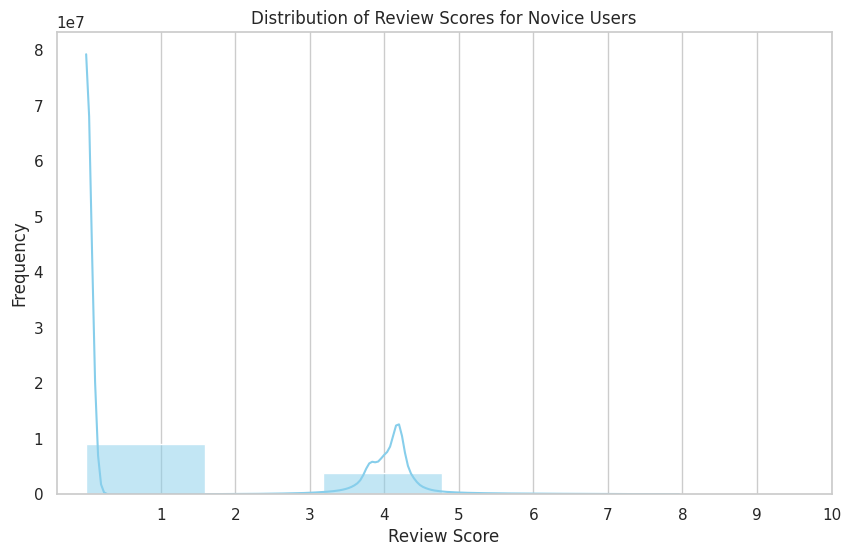

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(novice_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Novice Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [ ]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=novice_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Novice Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

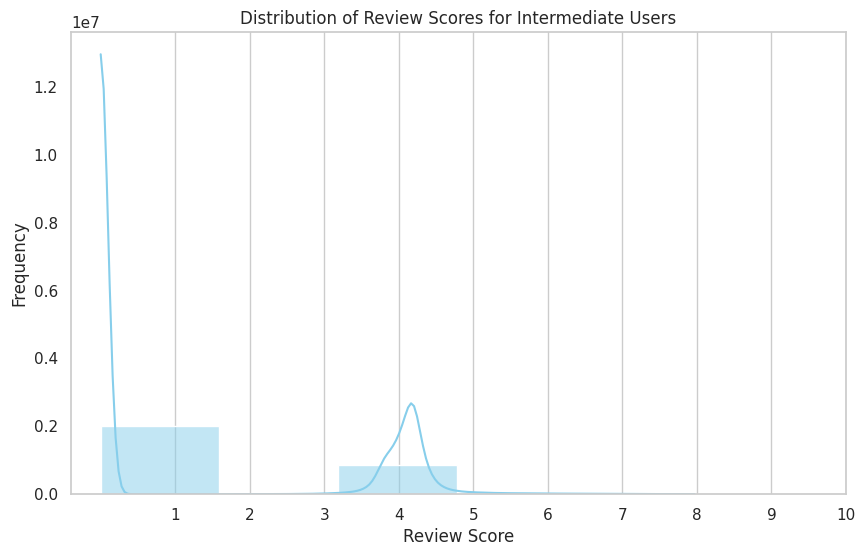

In [16]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(intermediate_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Intermediate Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [ ]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=intermediate_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Intermediate Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

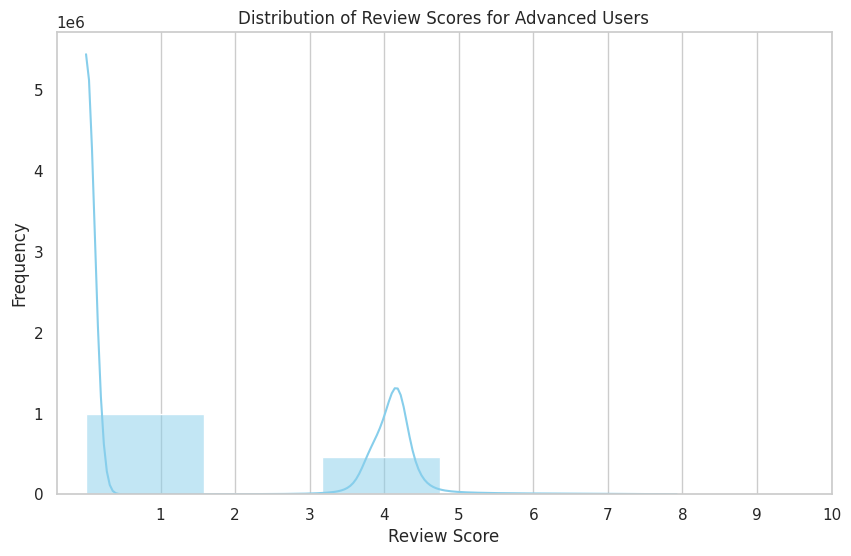

In [17]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(advanced_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Advanced Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [ ]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=advanced_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Advanced Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

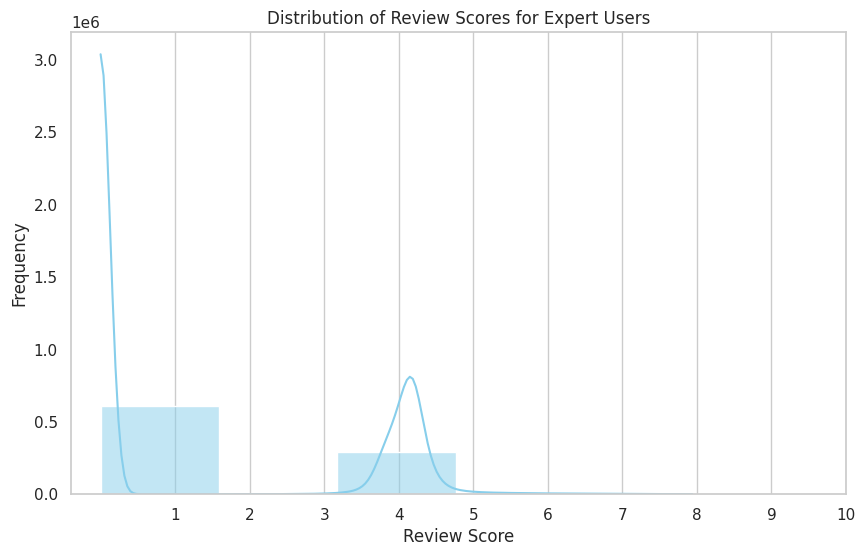

In [18]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(expert_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Expert Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [ ]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=expert_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Expert Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

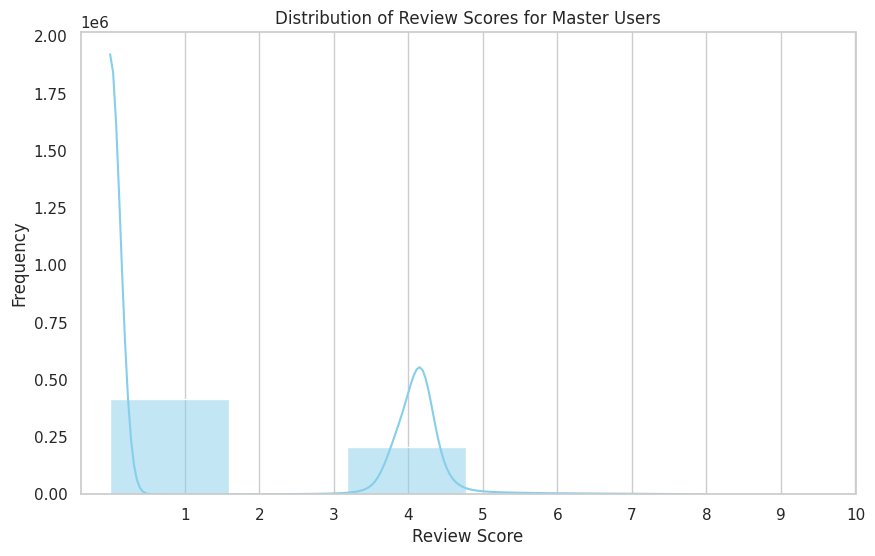

In [19]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(master_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Master Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [ ]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=master_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Master Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

In [ ]:
# plt.figure(figsize=(12, 6))
# sns.boxplot(x='experience_level', y='avg_review_score', data=grouped_df, palette='Set2')
# plt.title('Review Score Distribution by User Experience Level')
# plt.xlabel('User Experience Level')
# plt.ylabel('Review Score')
# plt.show()

In [23]:
from scipy.stats import kruskal

In [24]:
# Separate review scores by experience level
novice_scores = grouped_df[grouped_df['experience_level'] == 'Novice']['avg_review_score']
intermediate_scores = grouped_df[grouped_df['experience_level'] == 'Intermediate']['avg_review_score']
advanced_scores = grouped_df[grouped_df['experience_level'] == 'Advanced']['avg_review_score']
expert_scores = grouped_df[grouped_df['experience_level'] == 'Expert']['avg_review_score']
master_scores = grouped_df[grouped_df['experience_level'] == 'Master']['avg_review_score']

# Perform Kruskal-Wallis H Test
stat, p_value = kruskal(novice_scores, intermediate_scores, advanced_scores, expert_scores, master_scores)
print("Kruskal-Wallis H Test")
print("Statistic:", stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in review score distributions across user experience levels.")
else:
    print("There is no statistically significant difference in review score distributions across user experience levels.")


Kruskal-Wallis H Test
Statistic: 9592.841734405602
P-value: 0.0
There is a statistically significant difference in review score distributions across user experience levels.


The results indicate that there is a statistically significant difference in the distribution of review scores among users of different experience levels (Novice, Intermediate, Advanced, Expert, and Master). This implies that the average review scores are likely affected by the users' experience levels, meaning some experience groups tend to have higher or lower scores than others.

#### 4) d)

The results of the Kruskal-Wallis H Test indicate a statistically significant difference in average review scores among users of varying experience levels, with a test statistic of approximately 9592.84 and a p-value of 0.0. This suggests that user experience significantly influences how ratings are given. Potential explanations for this trend include varying expectations based on expertise—where more experienced users may rate lower due to heightened standards or higher due to greater familiarity with the app's features. Additionally, the time spent on the app could lead to different user perceptions and engagement levels, which may further impact ratings. 